# 01 · Probability for Bayesian Learning

*Companion notebook for the chapter* **Probability**

Everything a BNN does is probability. This notebook builds the tools step by step, simulating each idea in Python so the formulas become concrete.

**Contents**
1. Random experiments and their outcomes
2. Conditional probability and Bayes' rule
3. Random variables
4. Probability distributions
5. Conditional distributions and Bayes' rule for distributions
6. Predictive distributions
7. Bayesian learning and prediction — the full loop

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1. Random experiments and their outcomes

A **random experiment** has a set of possible outcomes, the **sample space** $\Omega$. Rolling a die: $\Omega=\{1,2,3,4,5,6\}$.
An **event** is a subset, e.g. $A=\{\text{even}\}=\{2,4,6\}$, with $P(A)=3/6$.

The *frequentist* reading of probability: the relative frequency of $A$ approaches $P(A)$ as we repeat the experiment (law of large numbers).

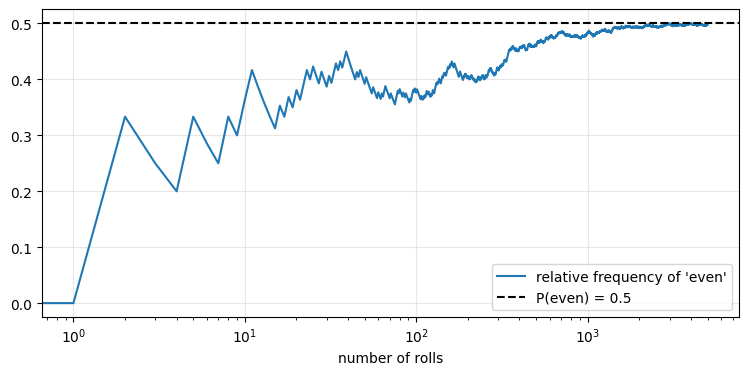

In [2]:
rolls = rng.integers(1, 7, size=5000)
is_even = (rolls % 2 == 0)
running_freq = np.cumsum(is_even) / np.arange(1, len(rolls) + 1)

plt.plot(running_freq, label="relative frequency of 'even'")
plt.axhline(0.5, c="k", ls="--", label="P(even) = 0.5")
plt.xscale("log"); plt.xlabel("number of rolls"); plt.legend(); plt.show()

## 2. Conditional probability and Bayes' rule

The probability of $A$ **given** that $B$ happened:

$$P(A\mid B) = \frac{P(A\cap B)}{P(B)}$$

Example with two dice: $P(\text{sum}=8 \mid \text{first die}=3)$. Exactly: the second die must be 5, so the answer is $1/6$.

In [3]:
d1, d2 = rng.integers(1, 7, 200_000), rng.integers(1, 7, 200_000)
B = d1 == 3
A_and_B = (d1 + d2 == 8) & B
print(f"Simulated P(sum=8 | first=3) = {A_and_B.sum() / B.sum():.4f}   (exact 1/6 = {1/6:.4f})")
print(f"Simulated P(sum=8)            = {(d1 + d2 == 8).mean():.4f}   (exact 5/36 = {5/36:.4f})")

Simulated P(sum=8 | first=3) = 0.1662   (exact 1/6 = 0.1667)
Simulated P(sum=8)            = 0.1381   (exact 5/36 = 0.1389)


Writing $P(A\cap B)$ in two ways gives **Bayes' rule**:

$$\boxed{P(H\mid D) = \frac{P(D\mid H)\,P(H)}{P(D)}}\qquad
\text{posterior} = \frac{\text{likelihood}\times\text{prior}}{\text{evidence}}$$

### A classic: a medical test
* 1% of people have a disease: $P(H)=0.01$
* The test detects it 95% of the time: $P(+\mid H)=0.95$
* False positive rate 5%: $P(+\mid \neg H)=0.05$

If a test is positive, what is $P(H\mid +)$?

In [4]:
p_H, p_pos_H, p_pos_notH = 0.01, 0.95, 0.05
p_pos = p_pos_H * p_H + p_pos_notH * (1 - p_H)       # law of total probability
p_H_pos = p_pos_H * p_H / p_pos
print(f"P(disease | positive) = {p_H_pos:.3f}")

# check by simulation
N = 1_000_000
sick = rng.random(N) < p_H
positive = np.where(sick, rng.random(N) < p_pos_H, rng.random(N) < p_pos_notH)
print(f"simulated             = {sick[positive].mean():.3f}")

P(disease | positive) = 0.161
simulated             = 0.159


Only about **16%**! The prior (the disease is rare) matters a lot. BNNs work the same way: the prior over weights combines with the evidence in the data.

**Sequential updating** — today's posterior is tomorrow's prior. What if a second, independent test is also positive?

In [5]:
prior = p_H
for test in range(1, 4):
    post = p_pos_H * prior / (p_pos_H * prior + p_pos_notH * (1 - prior))
    print(f"after {test} positive test(s): P(disease) = {post:.3f}")
    prior = post

after 1 positive test(s): P(disease) = 0.161
after 2 positive test(s): P(disease) = 0.785
after 3 positive test(s): P(disease) = 0.986


## 3. Random variables

A **random variable** $X$ maps each outcome to a number. Discrete variables have a **probability mass function** $p(x)=P(X=x)$; continuous ones have a **probability density function** $p(x)$ with $P(a\le X\le b)=\int_a^b p(x)\,dx$.

Two summaries we use constantly:

$$\mathbb E[X]=\sum_x x\,p(x) \;\;\Big(\text{or}\int x\,p(x)\,dx\Big),\qquad \operatorname{Var}[X]=\mathbb E\big[(X-\mathbb E[X])^2\big]$$

In [6]:
X = rng.integers(1, 7, 100_000)     # a fair die as a random variable
print("E[X]  simulated", X.mean().round(3), " exact", 3.5)
print("Var[X] simulated", X.var().round(3), " exact", round(35 / 12, 3))

E[X]  simulated 3.494  exact 3.5
Var[X] simulated 2.924  exact 2.917


## 4. Probability distributions

Four distributions appear again and again in BNNs:

* **Bernoulli**$(\theta)$ — one coin flip; the likelihood of a binary classifier.
* **Binomial**$(n,\theta)$ — number of heads in $n$ flips.
* **Gaussian** $\mathcal N(\mu,\sigma^2)$ — regression noise, and the usual **prior over weights**.
* **Beta**$(a,b)$ — a distribution over a probability $\theta\in[0,1]$; the conjugate prior for the Bernoulli.

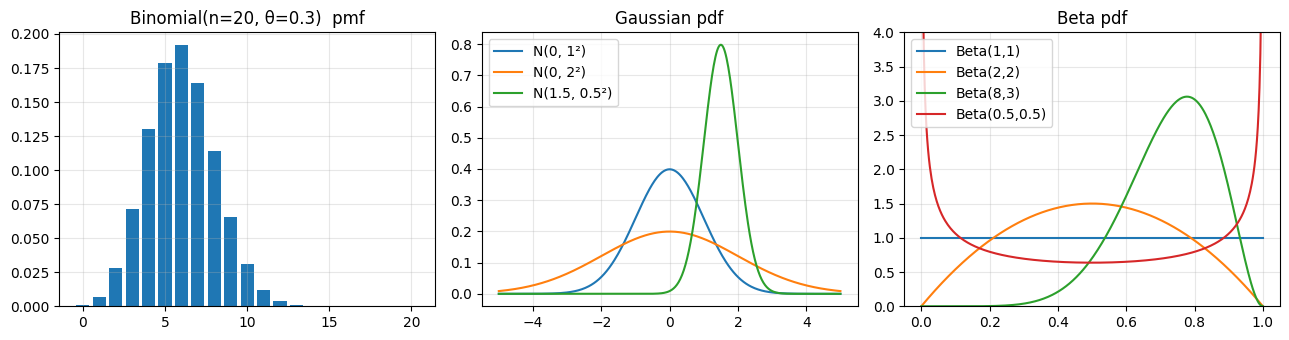

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
k = np.arange(0, 21)
ax[0].bar(k, stats.binom.pmf(k, 20, 0.3)); ax[0].set_title("Binomial(n=20, θ=0.3)  pmf")

x = np.linspace(-5, 5, 400)
for mu, s in [(0, 1), (0, 2), (1.5, 0.5)]:
    ax[1].plot(x, stats.norm.pdf(x, mu, s), label=f"N({mu}, {s}²)")
ax[1].legend(); ax[1].set_title("Gaussian pdf")

t = np.linspace(0, 1, 400)
for a, b in [(1, 1), (2, 2), (8, 3), (0.5, 0.5)]:
    ax[2].plot(t, stats.beta.pdf(t, a, b), label=f"Beta({a},{b})")
ax[2].set_ylim(0, 4); ax[2].legend(); ax[2].set_title("Beta pdf")
plt.tight_layout(); plt.show()

## 5. Conditional distributions and Bayes' rule for distributions

Now the unknown is a **parameter** $\theta$ (the bias of a coin), not an event. Bayes' rule becomes a statement about *whole distributions*:

$$p(\theta\mid\mathcal D)=\frac{p(\mathcal D\mid\theta)\,p(\theta)}{\int p(\mathcal D\mid\theta')\,p(\theta')\,d\theta'}$$

With a Beta$(a,b)$ prior and $h$ heads in $n$ flips (Bernoulli likelihood $\theta^h(1-\theta)^{n-h}$), the posterior is again Beta:

$$p(\theta\mid\mathcal D)=\text{Beta}(a+h,\; b+n-h)$$

This is the whole story of a BNN in miniature — only there, $\theta$ is millions of weights and the integral has no closed form.

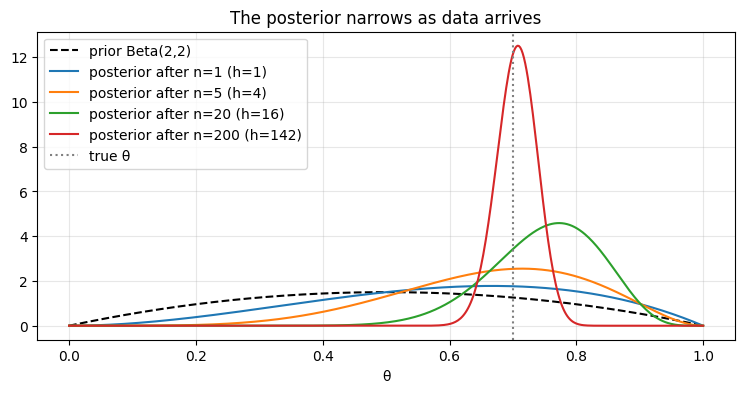

In [8]:
theta_true = 0.7
flips = rng.random(200) < theta_true
a0, b0 = 2, 2                               # prior: "probably fair-ish"

t = np.linspace(0, 1, 500)
plt.plot(t, stats.beta.pdf(t, a0, b0), "k--", label="prior Beta(2,2)")
for n in [1, 5, 20, 200]:
    h = flips[:n].sum()
    plt.plot(t, stats.beta.pdf(t, a0 + h, b0 + n - h), label=f"posterior after n={n} (h={h})")
plt.axvline(theta_true, c="gray", ls=":", label="true θ")
plt.xlabel("θ"); plt.legend(); plt.title("The posterior narrows as data arrives"); plt.show()

### Doing it numerically (grid approximation)
When there is no conjugate formula, we can still evaluate *prior × likelihood* on a grid and normalise. This is the brute-force idea behind every approximate method.

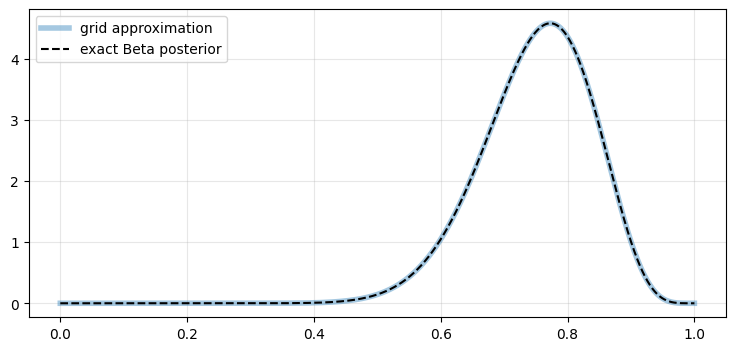

In [9]:
n, h = 20, flips[:20].sum()
grid = np.linspace(0, 1, 1001)
unnorm = stats.beta.pdf(grid, a0, b0) * grid**h * (1 - grid)**(n - h)
post_grid = unnorm / np.trapezoid(unnorm, grid)

plt.plot(grid, post_grid, lw=4, alpha=0.4, label="grid approximation")
plt.plot(grid, stats.beta.pdf(grid, a0 + h, b0 + n - h), "k--", label="exact Beta posterior")
plt.legend(); plt.show()

## 6. Predictive distributions

We rarely care about $\theta$ itself — we want to predict the **next** flip. The **posterior predictive** averages the likelihood over the posterior:

$$p(y^*\mid\mathcal D)=\int p(y^*\mid\theta)\,p(\theta\mid\mathcal D)\,d\theta$$

For the coin: $P(y^*=\text{heads}\mid\mathcal D)=\dfrac{a+h}{a+b+n}$.

Compare with the **plug-in** prediction that uses only the maximum-likelihood estimate $\hat\theta=h/n$. After 3 heads in 3 flips the plug-in predicts heads with certainty — the Bayesian answer stays humble.

In [10]:
for n, h in [(3, 3), (10, 8), (100, 70)]:
    mle = h / n
    bayes = (a0 + h) / (a0 + b0 + n)
    print(f"n={n:3d}, h={h:3d}:  plug-in MLE P(heads)={mle:.3f}   Bayesian predictive={bayes:.3f}")

n=  3, h=  3:  plug-in MLE P(heads)=1.000   Bayesian predictive=0.714
n= 10, h=  8:  plug-in MLE P(heads)=0.800   Bayesian predictive=0.714
n=100, h= 70:  plug-in MLE P(heads)=0.700   Bayesian predictive=0.692


The predictive for a *batch* of future flips is the **Beta-Binomial** distribution — wider than a Binomial with a plug-in $\hat\theta$, because it includes our uncertainty about $\theta$.

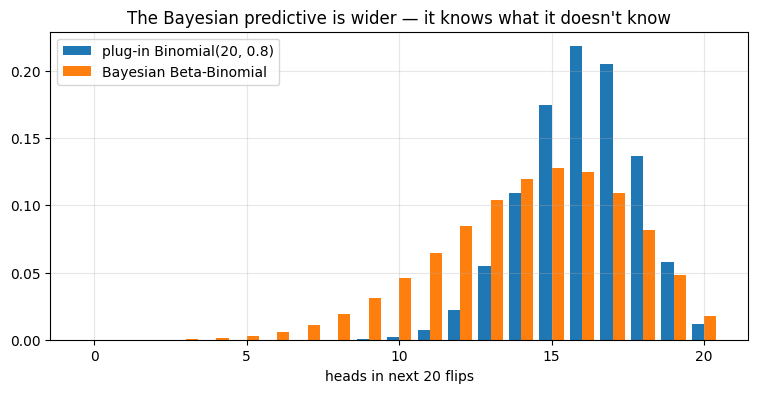

In [11]:
n, h, m = 10, 8, 20                                   # after 10 flips, predict heads in next 20
k = np.arange(m + 1)
plt.bar(k - 0.2, stats.binom.pmf(k, m, h / n), width=0.4, label="plug-in Binomial(20, 0.8)")
plt.bar(k + 0.2, stats.betabinom.pmf(k, m, a0 + h, b0 + n - h), width=0.4, label="Bayesian Beta-Binomial")
plt.xlabel("heads in next 20 flips"); plt.legend(); plt.title("The Bayesian predictive is wider — it knows what it doesn't know"); plt.show()

## 7. Bayesian learning and prediction — the full loop

1. **Model**: choose a likelihood $p(\mathcal D\mid\theta)$ and a prior $p(\theta)$.
2. **Learn**: compute the posterior $p(\theta\mid\mathcal D)\propto p(\mathcal D\mid\theta)\,p(\theta)$.
3. **Predict**: average over the posterior, $p(y^*\mid x^*,\mathcal D)=\int p(y^*\mid x^*,\theta)\,p(\theta\mid\mathcal D)\,d\theta$.

In a **Bayesian Neural Network**, $\theta$ = all the weights, the likelihood is defined by the network's output, and step 2 has to be approximated (notebooks 05–08).

## Exercises
1. Repeat the medical test with a prevalence of 10%. How does $P(H\mid +)$ change?
2. Use a very strong prior Beta(50, 50). How many flips are needed before the posterior mean exceeds 0.65?
3. Show algebraically that the posterior mean $\frac{a+h}{a+b+n}$ lies between the prior mean $\frac{a}{a+b}$ and the MLE $\frac hn$.